# Tier 22: design-space practice

Plan 029. Tooling around the Halo sizing solve, without changing the sizing. The aircraft studied here is the
plan 027 reference (900 kg, 210 kt, AeroBuildup, AFDD tiltrotor wing, equivalent-circuit battery, minimum take-off
mass, 13,639 lb; `assumptions_plan027`), i.e. without the Tier 19 thermal model, which plan 030 made the default
(14,037 lb, about 4 minutes per solve). The tooling applies unchanged to the thermal-on default, whose start list
begins with the thermal-off problem:

1. **Starting-point strategy:** an ordered list of candidate starts, each one independent coupled solve; the first
   that converges is returned (or the best of all, `select="best"`) with a record of every attempt.
2. **Freed trades:** wing aspect ratio, mission cruise altitude and reserve SOC as design variables, behind flags.
3. **Cost objective:** `objective="cost"`, acquisition plus operating cost per mission (`CostModel`).
4. **Architecture enumeration** over existing flags, as separate solves.
5. **Robustness:** one-at-a-time sensitivity of take-off mass to uncertain inputs (tornado).

**Aerodynamics used:** an AeroBuildup solve takes 2-3 minutes, so the reference, its local-optimum spread, the
cost-optimal reference and the combined freed trades use AeroBuildup; the sweeps (single freed trades, cost
sweep, enumeration, sensitivity) use `aerodynamics_model="scholz"` (about 8 s per solve, within about 1 % in mass
of AeroBuildup, plan 025). Every table says which model it used.

```powershell
uv run jupyter lab notebooks/tier22_design_space
```

In [1]:
import sys
import time
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for path in (repo_root / "src", repo_root):     # this checkout's package even if another one is installed
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.mission.cost import CostModel
from examples.halo_design_space import default_uncertain_inputs, enumerate_architectures, sensitivity_study
from examples.halo_sizing import (HaloAssumptions, HaloRequirements, assumptions_plan026, assumptions_plan027,
                                  default_starts,
                                  requirements_plan026, solve_halo_sizing, solve_halo_sizing_multistart)

check_log = []


def check(name, passed):
    # Record and print one named verification.
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def lb(mass_kg):
    return mass_kg / u.lbm


def show_record(result):
    print(f"returned start: {result.start.label}")
    for a in result.start.attempts:
        mass = f"{lb(a.mass_takeoff_kg):9,.0f} lb" if a.success else " " * 12
        print(f"  {a.label:22s} {'converged' if a.success else 'failed   '} {mass} {a.time_s:6.0f} s  {a.message[-70:]}")


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow, red = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#d03b3b"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8,
                     "axes.labelcolor": ink, "xtick.color": ink_muted, "ytick.color": ink_muted})
requirements = HaloRequirements()
# The plan 027 aircraft (thermal model off). Plan 030 made the thermal model the default (14,037 lb, about 4 min
# per solve); the design-space studies use the thermal-off aircraft to stay fast.
reference_assumptions = assumptions_plan027
scholz = replace(reference_assumptions, aerodynamics_model="scholz")
t_notebook = time.time()

## 1. The reference from cold, and its local-optimum spread (AeroBuildup)

The plan 027 aircraft, with the Tier 19 thermal model pinned off (with it on, the start list begins with the
thermal-off problem, `"thermal_off"`). `solve_halo_sizing()` with no `initial` now runs
`solve_halo_sizing_multistart`. For the reference the default
candidate list is below. Here three of them are run to completion (`select="best"`): the Scholz-aero start (the
plan 025 rule, which the default `"first"` mode returns) and the Scholz design scaled by 0.85 and 1.15. Different
local optima would show up as a mass spread.

In [2]:
print("default starts for the reference:", default_starts(requirements, reference_assumptions, "mass_takeoff"))
print("with the thermal model on:       ", default_starts(requirements, replace(reference_assumptions, thermal_model=True),
                                                         "mass_takeoff"))
t0 = time.time()
reference = solve_halo_sizing_multistart(assumptions=reference_assumptions, select="best",
                                         starts=("scholz_aero", "perturbed_low", "perturbed_high"))
print(f"{lb(reference.mass_takeoff_kg):,.0f} lb in {time.time() - t0:.0f} s")
show_record(reference)
spread_reference_kg = reference.start.spread_mass_takeoff_kg()
print(f"local-optimum spread over {len(reference.start.successes())} converged starts: {spread_reference_kg:.3f} kg")
check("reference unchanged: 13,639 lb (within 15 lb)", abs(lb(reference.mass_takeoff_kg) - 13639) < 15)
check("the Scholz-aero start is returned (ties go to the earlier start)", reference.start.label == "scholz_aero")
check("at least two starts converge on the reference", len(reference.start.successes()) >= 2)

default starts for the reference: ('scholz_aero', 'constant_battery', 'payload_continuation', 'perturbed_low', 'perturbed_high', 'generic')
with the thermal model on:        ('thermal_off', 'scholz_aero', 'constant_battery', 'payload_continuation', 'perturbed_low', 'perturbed_high', 'generic')


CasADi - 2026-10-04 16:02:52 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:02:53 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:09:34 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 69, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:09:35 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 48, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:09:35 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 48, col 0).") [.../casadi/core/oracle_function.cpp:408]


...

CasADi - 2026-10-04 16:10:32 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 48, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:10:32 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 198, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:32 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 198, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:32 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 317, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:10:33 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 317, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:33 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 317, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:10:34 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 198, col 0).") [.../casadi/core/oracle_function.cpp:408]


13,639 lb in 547 s
returned start: scholz_aero
  scholz_aero            converged    13,639 lb    150 s  
  perturbed_low          converged    13,639 lb    143 s  
  perturbed_high         failed                    251 s   the latest values of variables. return_status is 'Restoration_Failed'
local-optimum spread over 2 converged starts: 0.000 kg
PASS  reference unchanged: 13,639 lb (within 15 lb)
PASS  the Scholz-aero start is returned (ties go to the earlier start)
PASS  at least two starts converge on the reference


## 2. The previously fragile cases, with no hand-supplied `initial`

- **900 kg equivalent-circuit pack with `SimpleAerodynamics`** (plan 026 sets): IPOPT fails from the
  constant-battery design; the 85 % payload design works.
- **Equivalent-circuit maximum payload** (Scholz aero): IPOPT fails from the constant-battery design (plan 022
  supplied a constant-battery max-payload design by hand); a perturbed start converges.
- **Best of all starts** on the Scholz reference: every default start, to show whether they agree.

In [3]:
t0 = time.time()
plan026 = solve_halo_sizing(requirements_plan026, assumptions_plan026)
print(f"plan 026 (simple aero, 900 kg): {lb(plan026.mass_takeoff_kg):,.0f} lb in {time.time() - t0:.0f} s")
show_record(plan026)
check("plan 026 900 kg ECM solves from cold at 14,247 lb", abs(lb(plan026.mass_takeoff_kg) - 14247) < 5)
check("plan 026: constant-battery start fails, payload continuation succeeds",
      [a.success for a in plan026.start.attempts] == [False, True]
      and plan026.start.label == "payload_continuation")

t0 = time.time()
payload = solve_halo_sizing(assumptions=scholz, objective="payload")
print(f"\nmax payload (Scholz, ECM): {payload.mass_payload_kg:,.0f} kg at {lb(payload.mass_takeoff_kg):,.0f} lb "
      f"in {time.time() - t0:.0f} s")
show_record(payload)
check("ECM max payload solves without initial", payload.min_margin > -1e-6 and payload.mass_payload_kg > 1500)

t0 = time.time()
scholz_best = solve_halo_sizing_multistart(assumptions=scholz, select="best")
print(f"\nScholz reference, every default start: {time.time() - t0:.0f} s")
show_record(scholz_best)
spread_scholz_kg = scholz_best.start.spread_mass_takeoff_kg()
print(f"spread: {spread_scholz_kg:.4f} kg over {len(scholz_best.start.successes())} converged starts")
check("Scholz reference: all converged starts reach the same optimum (spread < 1 kg)", spread_scholz_kg < 1.0)

CasADi - 2026-10-04 16:10:52 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 297, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:52 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 49, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:52 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 297, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:52 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 297, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:52 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:52 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:52 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 6

CasADi - 2026-10-04 16:10:52 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:52 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 297, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:10:52 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:53 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:10:53 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:53 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:53 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:53 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:10:53 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 297, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:53 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 297, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:53 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 297, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:53 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 297, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:53 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 297, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:53 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 297, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:10:53 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 

...

CasADi - 2026-10-04 16:12:24 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:12:24 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:12:24 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:12:25 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:12:25 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:12:25 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:12:25 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:12:25 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:12:25 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:12:25 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:12:25 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:12:25 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 

CasADi - 2026-10-04 16:12:31 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:12:42 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 184, col 0).") [.../casadi/core/oracle_function.cpp:408]



Scholz reference, every default start: 56 s
returned start: constant_battery
  constant_battery       converged    13,702 lb      6 s  
  payload_continuation   converged    13,702 lb     34 s  
  perturbed_low          converged    13,702 lb      5 s  
  perturbed_high         converged    13,702 lb      6 s  
  generic                converged    13,702 lb      5 s  
spread: 0.0000 kg over 5 converged starts
PASS  Scholz reference: all converged starts reach the same optimum (spread < 1 kg)


## 3. Freed trades

Each flag turns a fixed assumption into a bounded design variable:

| Flag | Variable | Bounds | Rationale |
|---|---|---|---|
| `free_aspect_ratio_wing` | wing aspect ratio (fixed 6.12, XV-15) | 4-12 | induced drag against wing weight, whirl-flutter stiffness and rotor-span clearance |
| `free_altitude_cruise` | mission cruise and loiter altitude (fixed 10,000 ft) | 2,000-13,000 ft | drag at a given speed against turboshaft lapse and climb energy; the 210 kt requirement stays at 10,000 ft |
| `free_soc_reserve` | reserve SOC: mission floor and engine-out start (fixed 0.30) | 0.20-0.90 | mission battery energy against engine-out voltage sag |

Single trades on the Scholz reference, all three together on the AeroBuildup reference; each through the
starting-point strategy with the fixed-value design as the first ("caller") start.

In [4]:
base_scholz = scholz_best
freed_flags = {"aspect ratio": dict(free_aspect_ratio_wing=True), "cruise altitude": dict(free_altitude_cruise=True),
               "reserve SOC": dict(free_soc_reserve=True)}
freed = {}
for name, flags in freed_flags.items():
    t0 = time.time()
    freed[name] = solve_halo_sizing_multistart(assumptions=replace(scholz, **flags), initial=base_scholz)
    print(f"{name}: {time.time() - t0:.0f} s, start {freed[name].start.label}")
t0 = time.time()
all_flags = dict(free_aspect_ratio_wing=True, free_altitude_cruise=True, free_soc_reserve=True)
freed_buildup = solve_halo_sizing_multistart(assumptions=replace(reference_assumptions, **all_flags), initial=reference)
print(f"all three, AeroBuildup: {time.time() - t0:.0f} s, start {freed_buildup.start.label}")


def describe(result):
    d = result.design
    return (f"AR {d.aspect_ratio_wing if d.aspect_ratio_wing is not None else 6.12:5.2f}  "
            f"alt {(d.altitude_cruise_m if d.altitude_cruise_m is not None else 3048.0) / u.foot:7,.0f} ft  "
            f"SOC res {d.soc_reserve if d.soc_reserve is not None else 0.30:.2f}  "
            f"wing {d.area_wing_m2:5.1f} m2  battery {result.energy_battery_kWh:5.1f} kWh  "
            f"fuel {result.mass_fuel_burnt_kg:4.0f} kg  cruise {result.velocity_cruise_m_s / u.knot:4.0f} kt")


print(f"\n{'case':28s}{'MTOM lb':>9s}{'delta lb':>10s}  design")
print(f"{'Scholz reference':28s}{lb(base_scholz.mass_takeoff_kg):9,.0f}{0:10.0f}  {describe(base_scholz)}")
for name, r in freed.items():
    print(f"{'Scholz, free ' + name:28s}{lb(r.mass_takeoff_kg):9,.0f}"
          f"{lb(r.mass_takeoff_kg - base_scholz.mass_takeoff_kg):10.0f}  {describe(r)}")
print(f"{'AeroBuildup reference':28s}{lb(reference.mass_takeoff_kg):9,.0f}{0:10.0f}  {describe(reference)}")
print(f"{'AeroBuildup, all three free':28s}{lb(freed_buildup.mass_takeoff_kg):9,.0f}"
      f"{lb(freed_buildup.mass_takeoff_kg - reference.mass_takeoff_kg):10.0f}  {describe(freed_buildup)}")
for name, r in list(freed.items()) + [("all, AeroBuildup", freed_buildup)]:
    check(f"freed {name}: closes with all margins", r.min_margin > -1e-6 and abs(r.closure_residual_kg) < 1e-5)
for name, r in freed.items():
    check(f"freed {name}: no heavier than the fixed value", r.mass_takeoff_kg <= base_scholz.mass_takeoff_kg + 0.5)
check("all three freed (AeroBuildup) no heavier than the reference",
      freed_buildup.mass_takeoff_kg <= reference.mass_takeoff_kg + 0.5)

CasADi - 2026-10-04 16:13:10 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 610, col 0).") [.../casadi/core/oracle_function.cpp:408]


aspect ratio: 17 s, start caller


cruise altitude: 11 s, start caller


CasADi - 2026-10-04 16:13:36 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 610, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:13:36 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 610, col 0).") [.../casadi/core/oracle_function.cpp:408]


...

CasADi - 2026-10-04 16:13:40 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 610, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:13:40 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 610, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:13:40 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 610, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:13:40 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 610, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:13:40 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 610, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:13:41 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 610, col 0).") [.../casadi/core/oracle_function.cpp:408]


reserve SOC: 20 s, start constant_battery


all three, AeroBuildup: 187 s, start caller

case                          MTOM lb  delta lb  design
Scholz reference               13,702         0  AR  6.12  alt  10,000 ft  SOC res 0.30  wing  21.5 m2  battery  56.5 kWh  fuel  784 kg  cruise  161 kt
Scholz, free aspect ratio      13,629       -73  AR  7.11  alt  10,000 ft  SOC res 0.30  wing  18.2 m2  battery  54.2 kWh  fuel  776 kg  cruise  163 kt
Scholz, free cruise altitude   13,552      -150  AR  6.12  alt  13,000 ft  SOC res 0.30  wing  21.3 m2  battery  54.9 kWh  fuel  763 kg  cruise  164 kt
Scholz, free reserve SOC       13,316      -386  AR  6.12  alt  10,000 ft  SOC res 0.90  wing  21.0 m2  battery  40.4 kWh  fuel  786 kg  cruise  160 kt
AeroBuildup reference          13,639         0  AR  6.12  alt  10,000 ft  SOC res 0.30  wing  21.4 m2  battery  55.8 kWh  fuel  769 kg  cruise  163 kt
AeroBuildup, all three free    13,078      -560  AR  6.81  alt  13,000 ft  SOC res 0.90  wing  18.5 m2  battery  37.6 kWh  fuel  745 kg  cr

## 4. Cost objective

`CostModel` (`src/aircraft_closure/mission/cost.py`), per mission: capital (airframe per kg, machines and
turboshafts per kW, over 7,000 missions), fuel, ground electricity to restore the take-off SOC, battery
replacement (cycle throughput over 1,000 equivalent cycles plus calendar life over 3,750 missions) and a cost per
flight hour (USD 500/h: maintenance, remote crew, ground operations). All prices are labelled assumptions; the
anchors are the BloombergNEF 2024 pack price, EIA jet fuel and commercial electricity prices.

The cost optimum is compared with the mass optimum on the AeroBuildup reference; the cost per flight hour, the
least certain item, is swept on the Scholz aircraft to show the cost-mass trade.

In [5]:
def cost_row(name, r):
    c = r.cost
    return (f"{name:30s}{lb(r.mass_takeoff_kg):9,.0f}{r.velocity_cruise_m_s / u.knot:7.0f}{r.mass_fuel_burnt_kg:7.0f}"
            f"{r.energy_battery_kWh:7.1f}{c.capital_usd:8.0f}{c.fuel_usd:7.0f}{c.electricity_usd:6.1f}"
            f"{c.battery_usd:7.1f}{c.time_usd:7.0f}{c.per_mission_usd:8.0f}{c.acquisition_usd / 1e6:7.2f}")


header = (f"{'design':30s}{'MTOM lb':>9s}{'kt':>7s}{'fuel':>7s}{'kWh':>7s}{'capital':>8s}{'fuel$':>7s}{'elec':>6s}"
          f"{'batt':>7s}{'time':>7s}{'$/msn':>8s}{'acq M$':>7s}")
t0 = time.time()
cost_optimal = solve_halo_sizing_multistart(assumptions=reference_assumptions, objective="cost", initial=reference)
print(f"AeroBuildup cost optimum, start {cost_optimal.start.label}: {time.time() - t0:.0f} s\n")
print(header)
print(cost_row("AeroBuildup, minimum mass", reference))
print(cost_row("AeroBuildup, minimum cost", cost_optimal))
check("cost optimum closes", cost_optimal.min_margin > -1e-6 and abs(cost_optimal.closure_residual_kg) < 1e-5)
check("cost optimum is no dearer than the mass optimum",
      cost_optimal.cost.per_mission_usd <= reference.cost.per_mission_usd + 1e-3)
check("mass optimum is no heavier than the cost optimum",
      reference.mass_takeoff_kg <= cost_optimal.mass_takeoff_kg + 1e-3)

CasADi - 2026-10-04 16:19:23 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:19:32 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:19:32 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:19:33 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:19:33 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:19:33 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:19:33 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:19:33 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:19:33 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:19:33 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:19:34 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:19:34 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:19:34 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


...

CasADi - 2026-10-04 16:34:27 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:34:27 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:34:27 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:34:27 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:34:28 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:34:28 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:34:28 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:34:37 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]


AeroBuildup cost optimum, start scholz_aero: 1171 s

design                          MTOM lb     kt   fuel    kWh capital  fuel$  elec   batt   time   $/msn acq M$
AeroBuildup, minimum mass        13,639    163    769   55.8     899    692   6.0   37.8   1556    3191   6.32
AeroBuildup, minimum cost        14,176    210    791   62.6     936    711  -0.0    8.5   1283    2939   6.58
PASS  cost optimum closes
PASS  cost optimum is no dearer than the mass optimum
PASS  mass optimum is no heavier than the cost optimum


CasADi - 2026-10-04 16:36:41 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:36:41 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]


USD     0/h:   29 s, start mass_objective


CasADi - 2026-10-04 16:37:11 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:37:11 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:11 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:11 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:11 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:11 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:11 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:11 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 

CasADi - 2026-10-04 16:37:12 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]


...

USD   500/h:   14 s, start mass_objective


CasADi - 2026-10-04 16:37:43 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 184, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:37:44 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:44 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:44 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:44 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:44 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:44 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:44 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 

CasADi - 2026-10-04 16:37:44 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:44 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:44 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:44 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:44 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:44 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:37:44 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 

USD  1000/h:   14 s, start mass_objective

design                          MTOM lb     kt   fuel    kWh capital  fuel$  elec   batt   time   $/msn acq M$
Scholz, minimum mass             13,702    161    784   56.5     901    705   6.1   38.5   1573    3224   6.33
Scholz, min cost at 0 $/h        13,822    173    785   57.8     910    707  -0.0    7.9      0    1625   6.40
Scholz, min cost at 250 $/h      14,195    204    802   63.6     934    722  -0.0    8.7    655    2320   6.57
Scholz, min cost at 500 $/h      14,303    210    814   66.2     938    733  -0.0    9.0   1283    2963   6.60
Scholz, min cost at 1000 $/h     14,303    210    814   66.2     938    733  -0.0    9.0   2567    4246   6.60
PASS  cost sweep: at least three of four cost optima converge


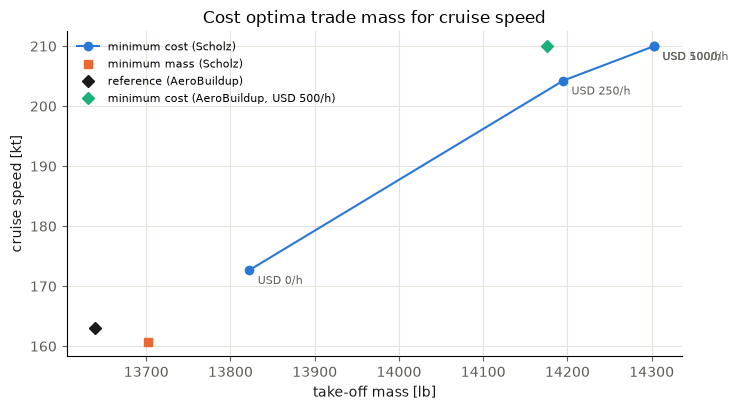

In [6]:
sweep_rates_usd_h = (0.0, 250.0, 500.0, 1000.0)
cost_sweep = {}
for rate in sweep_rates_usd_h:
    a = replace(scholz, cost_model=replace(CostModel(), cost_time_usd_s=rate / 3600))
    t0 = time.time()
    try:
        cost_sweep[rate] = solve_halo_sizing(assumptions=a, objective="cost")
        print(f"USD {rate:5.0f}/h: {time.time() - t0:4.0f} s, start {cost_sweep[rate].start.label}")
    except RuntimeError as error:
        print(f"USD {rate:5.0f}/h: no start converged ({time.time() - t0:.0f} s)")
print()
print(header)
print(cost_row("Scholz, minimum mass", base_scholz))
for rate, r in cost_sweep.items():
    print(cost_row(f"Scholz, min cost at {rate:.0f} $/h", r))
check("cost sweep: at least three of four cost optima converge", len(cost_sweep) >= 3)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
masses = [lb(r.mass_takeoff_kg) for r in cost_sweep.values()]
speeds = [r.velocity_cruise_m_s / u.knot for r in cost_sweep.values()]
ax.plot(masses, speeds, color=blue, marker="o", label="minimum cost (Scholz)")
for rate, m, v in zip(cost_sweep, masses, speeds):
    ax.annotate(f"USD {rate:.0f}/h", (m, v), textcoords="offset points", xytext=(6, -10), fontsize=8, color=ink_muted)
ax.plot(lb(base_scholz.mass_takeoff_kg), base_scholz.velocity_cruise_m_s / u.knot, "s", color=orange,
        label="minimum mass (Scholz)")
ax.plot(lb(reference.mass_takeoff_kg), reference.velocity_cruise_m_s / u.knot, "D", color=ink, label="reference (AeroBuildup)")
ax.plot(lb(cost_optimal.mass_takeoff_kg), cost_optimal.velocity_cruise_m_s / u.knot, "D", color=aqua,
        label="minimum cost (AeroBuildup, USD 500/h)")
ax.set(xlabel="take-off mass [lb]", ylabel="cruise speed [kt]", title="Cost optima trade mass for cruise speed")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 5. Architecture enumeration (Scholz aero)

Full factorial over four discrete choices that already exist as flags, each case a separate solve through the
starting-point strategy (shared precursor cache). The reference combination is the first row.

CasADi - 2026-10-04 16:38:27 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 247, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:38:27 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 29, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:38:27 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 247, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:38:27 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 247, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:38:27 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 247, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:38:27 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 247, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:38:27 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 247, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:38:27 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 247, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:38:27 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 

CasADi - 2026-10-04 16:38:28 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 247, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:38:29 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 29, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:38:29 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 247, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:38:29 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 247, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:38:29 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 29, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:38:29 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 247, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:38:29 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 24

CasADi - 2026-10-04 16:40:01 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 247, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:42:03 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 574, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:42:03 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 574, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:42:03 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 574, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:42:03 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 574, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:42:03 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 574, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:42:03 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 574, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:42:03 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 

...

  {'generator_step_up': False, 'rotor_speed_physics': False, 'wing_weight_model': 'afdd_tiltrotor', 'battery_model': 'ecm'}: max-payload problem did not converge either (34 s)


  {'generator_step_up': False, 'rotor_speed_physics': False, 'wing_weight_model': 'afdd_tiltrotor', 'battery_model': 'constant'}: max payload 628 kg at 18,849 lb (start generic, 3 s)


CasADi - 2026-10-04 16:49:47 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 28, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:49:47 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 28, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:49:47 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 28, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:49:47 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 28, col 0).") [.../casadi/core/oracle_function.cpp:408]


  {'generator_step_up': False, 'rotor_speed_physics': False, 'wing_weight_model': 'raymer', 'battery_model': 'ecm'}: max-payload problem did not converge either (44 s)


  {'generator_step_up': False, 'rotor_speed_physics': False, 'wing_weight_model': 'raymer', 'battery_model': 'constant'}: max payload 240 kg at 18,396 lb (start generic, 6 s)
3 combination(s) converge neither at 900 kg nor at maximum payload (open: not proven infeasible)
PASS  every converged maximum payload of a non-closing combination is below 900 kg


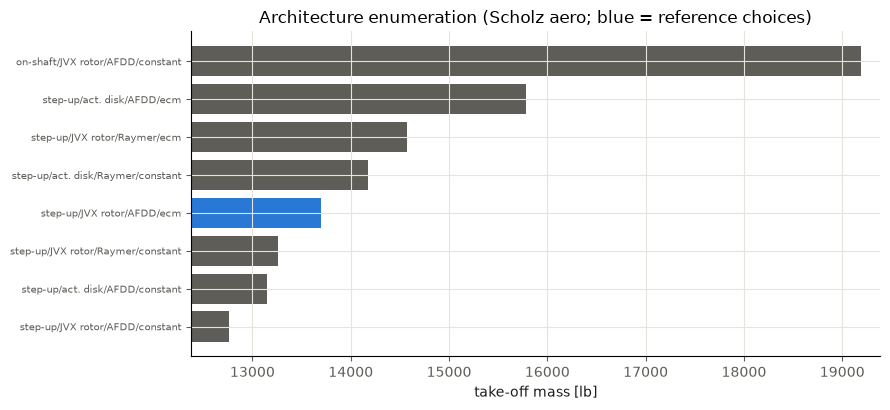

In [7]:
options = {"generator_step_up": (True, False), "rotor_speed_physics": (True, False),
           "wing_weight_model": ("afdd_tiltrotor", "raymer"), "battery_model": ("ecm", "constant")}
t0 = time.time()
cases = enumerate_architectures(options, assumptions=scholz)
print(f"{len(cases)} cases in {time.time() - t0:.0f} s\n")
print(f"{'step-up':>8s}{'rotor phys':>11s}{'wing':>15s}{'battery':>9s}{'MTOM lb':>10s}{'delta':>8s}{'kWh':>7s}"
      f"{'fuel kg':>8s}{'$/msn':>7s}{'start':>22s}{'s':>6s}")
reference_case = cases[0].result
for case in cases:
    s = dict(case.settings)
    prefix = (f"{str(s['generator_step_up']):>8s}{str(s['rotor_speed_physics']):>11s}{s['wing_weight_model']:>15s}"
              f"{s['battery_model']:>9s}")
    if case.converged:
        r = case.result
        print(f"{prefix}{lb(r.mass_takeoff_kg):10,.0f}{lb(r.mass_takeoff_kg - reference_case.mass_takeoff_kg):8.0f}"
              f"{r.energy_battery_kWh:7.1f}{r.mass_fuel_burnt_kg:8.0f}{r.cost.per_mission_usd:7.0f}"
              f"{r.start.label:>22s}{case.time_s:6.0f}")
    else:
        print(f"{prefix}{'no start converged':>40s}{case.time_s:30.0f}")
converged = [c for c in cases if c.converged]
check("enumeration: the reference combination is the Scholz reference",
      abs(reference_case.mass_takeoff_kg - base_scholz.mass_takeoff_kg) < 0.5)
check(f"enumeration: at least half of the {len(cases)} combinations close at 900 kg", 2 * len(converged) >= len(cases))

# Combinations that do not close at 900 kg: is 900 kg beyond their maximum payload at 210 kt?
print("\nmaximum payload of the combinations that did not close at 900 kg:")
explained = []
for case in (c for c in cases if not c.converged):
    s = dict(case.settings)
    t0 = time.time()
    try:
        r = solve_halo_sizing(assumptions=replace(scholz, **s), objective="payload")
        explained.append(r.mass_payload_kg < requirements.mass_payload_kg)
        print(f"  {s}: max payload {r.mass_payload_kg:,.0f} kg at {lb(r.mass_takeoff_kg):,.0f} lb "
              f"(start {r.start.label}, {time.time() - t0:.0f} s)")
    except RuntimeError:
        explained.append(None)
        print(f"  {s}: max-payload problem did not converge either ({time.time() - t0:.0f} s)")
unexplained = sum(1 for e in explained if e is None)
print(f"{unexplained} combination(s) converge neither at 900 kg nor at maximum payload (open: not proven infeasible)")
check("every converged maximum payload of a non-closing combination is below 900 kg",
      all(e for e in explained if e is not None))

fig, ax = plt.subplots(figsize=(9, 4.2))
labels = ["/".join(("step-up" if s["generator_step_up"] else "on-shaft", "JVX rotor" if s["rotor_speed_physics"]
                    else "act. disk", "AFDD" if s["wing_weight_model"] == "afdd_tiltrotor" else "Raymer",
                    s["battery_model"])) for s in (dict(c.settings) for c in converged)]
values = [lb(c.result.mass_takeoff_kg) for c in converged]
order = np.argsort(values)
ax.barh([labels[i] for i in order], [values[i] for i in order],
        color=[blue if converged[i] is cases[0] else ink_muted for i in order])
ax.set(xlabel="take-off mass [lb]", title="Architecture enumeration (Scholz aero; blue = reference choices)")
ax.set_xlim(min(values) * 0.97, max(values) * 1.01)
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

## 6. Robustness: sensitivity to uncertain inputs (Scholz aero, +/- 15 %)

One at a time, each input scaled by 0.85 and 1.15 and the aircraft re-sized (warm-started from the Scholz
reference, falling back to the starting-point strategy). The fittings drag area is shared by the Scholz and
AeroBuildup models; calibration factors are the XV-15 group-weight factors.

CasADi - 2026-10-04 16:50:28 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 297, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:50:31 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:31 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:31 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:31 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:50:37 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:37 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:37 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:37 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:37 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:37 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:37 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 

CasADi - 2026-10-04 16:50:45 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:45 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:45 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:45 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:45 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:45 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:45 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 

CasADi - 2026-10-04 16:50:55 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:55 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:55 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:55 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:55 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:55 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:50:55 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 

...

CasADi - 2026-10-04 16:53:46 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 184, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:53:46 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 184, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:53:46 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 184, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:53:46 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 184, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:53:46 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 184, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:53:46 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 184, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:53:46 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 

CasADi - 2026-10-04 16:53:46 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 184, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:53:46 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 184, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:53:46 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 184, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:53:49 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 184, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:53:53 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 184, col 0).") [.../casadi/core/oracle_function.cpp:408]


20 solves in 240 s

input                                 -15 % [lb]  +15 % [lb]
rotor calibration factor                    -499         551
fuselage calibration factor                 -540         546
powerplant calibration factor               -544         545
wing calibration factor                     -313         327
cell power-density factor                    305        -103
battery capacity at end of life              256         -67
fixed equipment mass                        -224         224
battery resistance at end of life            -88         192
fittings drag area                           -61          59
machine torque density                        50         -42
PASS  sensitivity: every case converged
PASS  more fittings drag needs a heavier aircraft
PASS  more fixed equipment needs a heavier aircraft


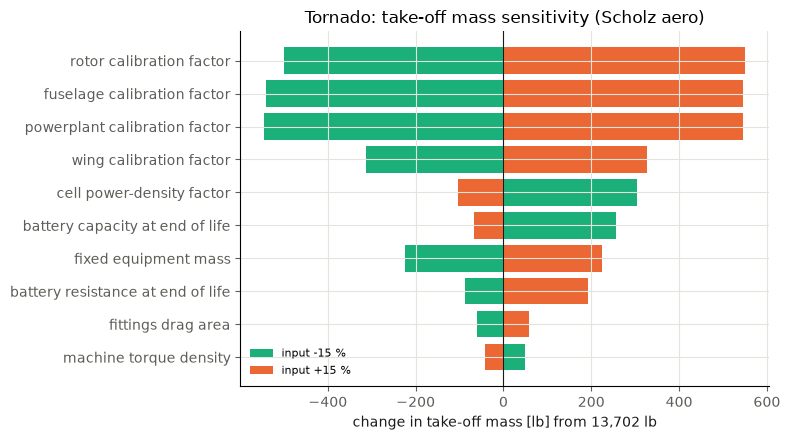

In [8]:
t0 = time.time()
study = sensitivity_study(assumptions=scholz, base=base_scholz, fraction=0.15)
print(f"{len(study.cases)} solves in {time.time() - t0:.0f} s\n")
rows = study.tornado()
print(f"{'input':36s}{'-15 % [lb]':>12s}{'+15 % [lb]':>12s}")
for label, low, high in rows:
    fmt = lambda x: f"{lb(x):12.0f}" if x is not None else f"{'failed':>12s}"
    print(f"{label:36s}{fmt(low)}{fmt(high)}")
check("sensitivity: every case converged", all(c.result is not None for c in study.cases))
fittings = next(r for r in rows if r[0] == "fittings drag area")
check("more fittings drag needs a heavier aircraft", fittings[1] < 0 < fittings[2])
equipment = next(r for r in rows if r[0] == "fixed equipment mass")
check("more fixed equipment needs a heavier aircraft", equipment[1] < 0 < equipment[2])

fig, ax = plt.subplots(figsize=(8, 4.5))
names = [r[0] for r in rows][::-1]
lows = [lb(r[1] or 0.0) for r in rows][::-1]
highs = [lb(r[2] or 0.0) for r in rows][::-1]
ax.barh(names, lows, color=aqua, label="input -15 %")
ax.barh(names, highs, color=orange, label="input +15 %")
ax.axvline(0, color=ink, lw=0.8)
ax.set(xlabel=f"change in take-off mass [lb] from {lb(base_scholz.mass_takeoff_kg):,.0f} lb",
       title="Tornado: take-off mass sensitivity (Scholz aero)")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 7. Summary

In [9]:
print(f"notebook solves: {(time.time() - t_notebook) / 60:.1f} min")
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

notebook solves: 52.7 min
25 / 25 notebook checks passed


In [10]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 518 tests in 1667.980s

OK (skipped=1)
